# CNN Advanced Model for Sarcasm Detection

This notebook implements a 1D Convolutional Neural Network (CNN) as an advanced model for sarcasm classification.

## 1. Import Required Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)

2.21.0


## 2. Load Datasets

In [5]:
train_df = pd.read_csv('C:/Users/baoya/Downloads/sarcasm_train.csv')
test_df = pd.read_csv('C:/Users/baoya/Downloads/sarcasm_test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

Train shape: (807972, 11)
Test shape: (201992, 11)


## 3. Prepare Text and Labels

In [6]:
text_col = 'combined_text'
label_col = 'label'

if text_col not in train_df.columns or text_col not in test_df.columns:
    raise ValueError("Both train and test files must contain a 'combined_text' column.")

if label_col not in train_df.columns or label_col not in test_df.columns:
    raise ValueError("Both train and test files must contain a 'label' column.")

X_train_text = train_df[text_col].fillna('').astype(str).values
y_train = train_df[label_col].values

X_test_text = test_df[text_col].fillna('').astype(str).values
y_test = test_df[label_col].values

print('Train label distribution:')
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

Train label distribution:
0    0.499397
1    0.500603
Name: proportion, dtype: float64


## 4. Tokenize and Pad Sequences

In [14]:
VOCAB_SIZE = 50000
MAX_LEN = 120
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('Padded train shape:', X_train_pad.shape)
print('Padded test shape:', X_test_pad.shape)

Padded train shape: (807972, 120)
Padded test shape: (201992, 120)


## 5. Build CNN Model

In [15]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

c:\Users\baoya\Desktop\CS 1521\Machine_learning-Project\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Train Model

In [ ]:
BATCH_SIZE = 128
EPOCHS = 12

classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print('Class weights:', class_weight)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=1e-4,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weight,
    verbose=1
)

Class weights: {0: 1.0012069422724716, 1: 0.9987959641311039}
Epoch 1/12
5682/5682 ━━━━━━━━━━━━━━━━━━━━ 1541s 271ms/step - accuracy: 0.6838 - auc: 0.7464 - loss: 0.5927 - val_accuracy: 0.7038 - val_auc: 0.7888 - val_loss: 0.5613 - learning_rate: 0.0010
Epoch 2/12
3700/5682 ━━━━━━━━━━━━━━━━━━━━ 8:13 249ms/step - accuracy: 0.7172 - auc: 0.7872 - loss: 0.5561

## 7. Evaluate on Test Set

In [10]:
test_loss, test_acc, test_auc = model.evaluate(X_test_pad, y_test, verbose=0)

y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

macro_f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test AUC: {test_auc:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, zero_division=0))
print('Confusion matrix [rows=true, cols=pred]:')
print(cm)

Test Loss: 0.5829
Test Accuracy: 0.6900
Test AUC: 0.7565
Macro F1: 0.6895

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70    101412
           1       0.70      0.65      0.68    100580

    accuracy                           0.69    201992
   macro avg       0.69      0.69      0.69    201992
weighted avg       0.69      0.69      0.69    201992

Confusion matrix [rows=true, cols=pred]:
[[73708 27704]
 [34907 65673]]


## 8. Plot Training Curves

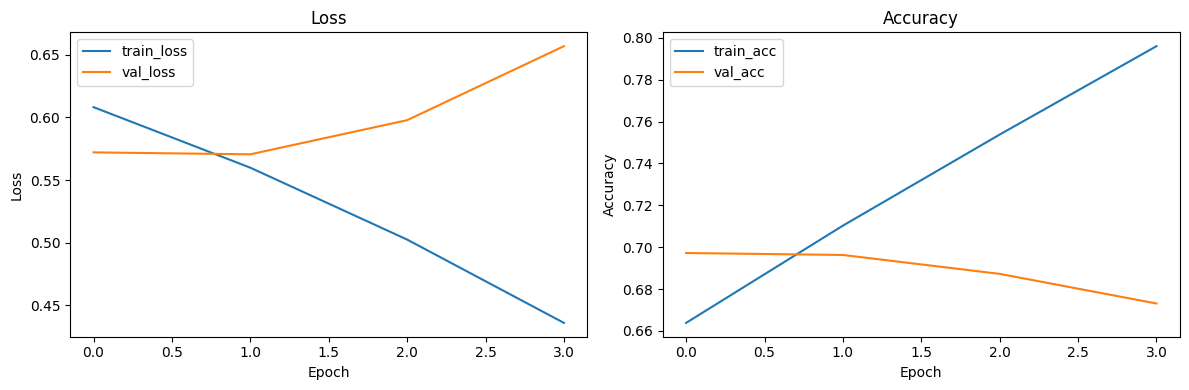

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print("Confusion Matrix:")
print(cm)

Test Loss: 0.5829
Test Accuracy: 0.6900
Test AUC: 0.7565
Macro F1: 0.6895
Confusion Matrix:
[[73708 27704]
 [34907 65673]]
